In [5]:
pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error 

In [33]:
data = pd.read_csv("Superstore.csv", encoding="ISO-8859-1")

data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [34]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [36]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [37]:
data['Day'] = data['Order Date'].dt.day
data['Month'] = data['Order Date'].dt.month
data['Year'] = data['Order Date'].dt.year

data[['Order Date','Year','Month']].head()

,Order Date,Year,Month
0,2016-11-08,2016,11
1,2016-11-08,2016,11
2,2016-06-12,2016,6
3,2015-10-11,2015,10
4,2015-10-11,2015,10


In [32]:
monthly_sales=data.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


In [38]:
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year','Month']].assign(DAY=1)
)

monthly_sales = monthly_sales.sort_values('Date')

monthly_sales.head()

,Year,Month,Sales,Date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28295.345,2014-04-01
4,2014,5,23648.287,2014-05-01


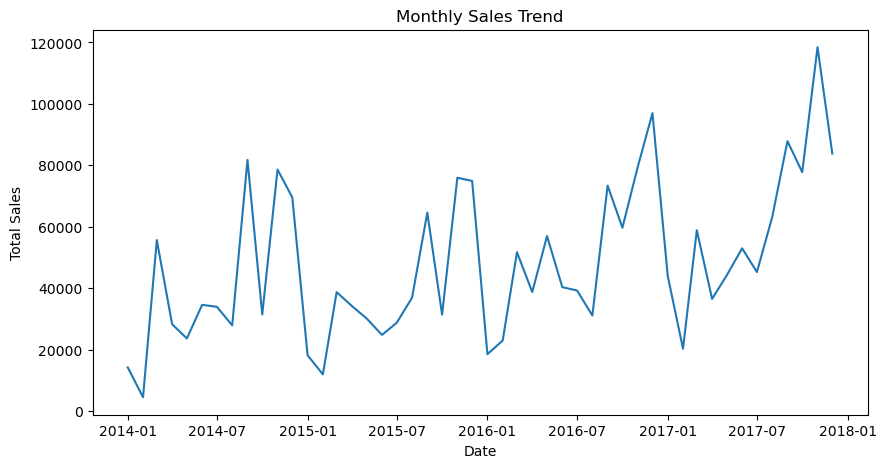

In [41]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [42]:
monthly_sales['Time_Index'] = range(len(monthly_sales))
monthly_sales.head()

,Year,Month,Sales,Date,Time_Index
0,2014,1,14236.895,2014-01-01,0
1,2014,2,4519.892,2014-02-01,1
2,2014,3,55691.009,2014-03-01,2
3,2014,4,28295.345,2014-04-01,3
4,2014,5,23648.287,2014-05-01,4


In [61]:
from sklearn.model_selection import train_test_split
X = monthly_sales[['Time_Index']]
y = monthly_sales['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [62]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 18041.639348494366


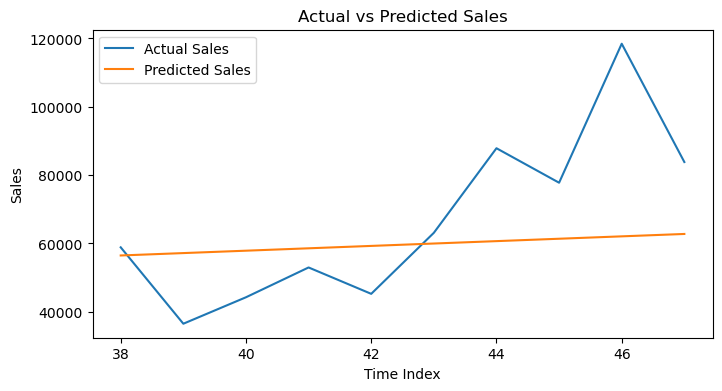

In [66]:
plt.figure(figsize=(8,4))
plt.plot(X_test, y_test, label="Actual Sales")
plt.plot(X_test, y_pred, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Time Index")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [67]:
X = monthly_sales[['Time_Index', 'Month']]
y = monthly_sales['Sales']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error
mae2 = mean_absolute_error(y_test, y_pred2)
print("Improved MAE:", mae2)

Improved MAE: 11599.752647027704


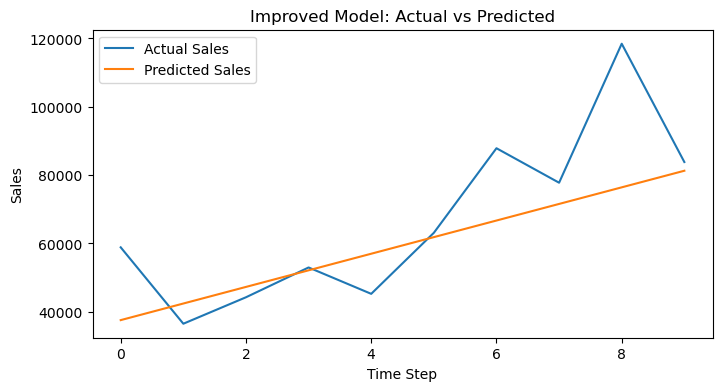

In [70]:
plt.figure(figsize=(8,4))

plt.plot(range(len(y_test)), y_test.values, label="Actual Sales")
plt.plot(range(len(y_pred2)), y_pred2, label="Predicted Sales")

plt.title("Improved Model: Actual vs Predicted")
plt.xlabel("Time Step")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [94]:
future_index = range(len(monthly_sales), len(monthly_sales)+8)
future_months = [(monthly_sales.iloc[-1]['Month'] + i - 1) % 12 + 1 for i in range(1,9)]
future_df = pd.DataFrame({
    'Time_Index': future_index,
    'Month': future_months
})
future_predictions = model2.predict(future_df)
future_predictions

array([33378.78573551, 38234.96716036, 43091.14858522, 47947.33001007,
       52803.51143493, 57659.69285978, 62515.87428464, 67372.05570949])

In [95]:
last_date = monthly_sales['Date'].max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=8,
    freq='MS'
)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Sales': future_predictions
})
forecast_df

,Date,Predicted Sales
0,2018-01-01,33378.785736
1,2018-02-01,38234.967160
2,2018-03-01,43091.148585
3,2018-04-01,47947.330010
4,2018-05-01,52803.511435
5,2018-06-01,57659.692860
6,2018-07-01,62515.874285
7,2018-08-01,67372.055709


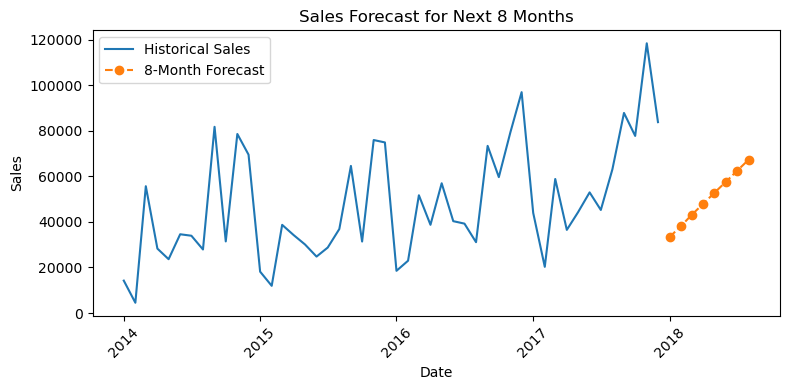

In [96]:
plt.figure(figsize=(8,4))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], label="Historical Sales")
plt.plot(forecast_df['Date'], forecast_df['Predicted Sales'], 
         marker='o', linestyle='--', label="8-Month Forecast")
plt.title("Sales Forecast for Next 8 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
